## Feature Engineering and Model Development 

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn Preprocessing & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, PrecisionRecallDisplay
)

# Linear & Parametric Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Non-Parametric & Single Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ensemble Models (Bagging & Boosting)
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Load the v1 halfway dataset (51 features)
df_raw = pd.read_csv('../data/v1/dataset_at_halfway.csv')
print(f"Dataset Loaded Successfully: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")


Dataset Loaded Successfully: 13,895 rows x 51 columns


### Feature Engineering & Data Preprocessing Pipeline

In [3]:
def preprocess_and_engineer_features(df_input):
    """
    Cleans data quality anomalies, handles outliers, builds composite challenge metrics,
    and applies domain risk personas based on EDA findings.
    """
    df = df_input.copy()

    # 1. Clip negative planned durations
    if 'planned_duration' in df.columns:
        df['planned_duration'] = df['planned_duration'].clip(lower=0)

    # 2. Outlier capping (99th percentile)
    if 'num_ma_revisions' in df.columns:
        df['num_ma_revisions'] = df['num_ma_revisions'].clip(upper=78)
    if 'num_revisions' in df.columns:
        df['num_revisions'] = df['num_revisions'].clip(upper=9)

    # 3. Composite Challenge Load Score
    challenge_cols = ['has_challenges', 'has_kpi_challenge', 'has_subtask_challenge', 'has_kpi_potential_challenge']
    existing_c = [c for c in challenge_cols if c in df.columns]
    if existing_c:
        df['total_challenge_load'] = df[existing_c].sum(axis=1)

    # 4. Risk Personas & Interaction Terms
    if 'num_revisions' in df.columns and 'has_challenges' in df.columns:
        df['persona_challenged_churn'] = ((df['num_revisions'] >= 3) & (df['has_challenges'] == 1)).astype(int)

    if 'is_cross_dept' in df.columns and 'kpi_is_overdue_flag' in df.columns:
        df['cross_dept_kpi_risk'] = ((df['is_cross_dept'] == 1) & (df['kpi_is_overdue_flag'] == 1)).astype(int)

    if 'planned_duration' in df.columns and 'num_revisions' in df.columns:
        df['duration_revision_intensity'] = df['num_revisions'] / (df['planned_duration'] + 1)

    # 5. Drop dead/weak/leakage features
    cols_to_drop = [
        'id', 'ma_comment_count', 'wl_low', 'created_is_weekend',
        'created_is_friday', 'kpi_comment_count',
        'subtask_completion_pct', 'subtask_overdue_rate'
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    return df

df_clean = preprocess_and_engineer_features(df_raw)
print(f"Cleaned Feature Table: {df_clean.shape[1] - 1} predictor features + 1 target column")


Cleaned Feature Table: 46 predictor features + 1 target column


### Data Splitting (Time-Based & 3-Way Train / Validation / Test)

In [4]:
# Sort chronologically by creation time (using month & quarter as proxy order)
df_sorted = df_clean.sort_values(by=['created_quarter', 'created_month']).reset_index(drop=True)

X = df_sorted.drop(columns=['calculated_overdue'])
y = df_sorted['calculated_overdue']

# 3-Way Time-Based Split: 70% Train, 15% Validation, 15% Test
n_total = len(df_sorted)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

X_train_time, y_train_time = X.iloc[:train_end], y.iloc[:train_end]
X_val_time, y_val_time = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test_time, y_test_time = X.iloc[val_end:], y.iloc[val_end:]

print(f"Time-Based Split Completed:")
print(f"  • Train Set: {len(X_train_time):,} rows ({y_train_time.mean()*100:.1f}% overdue)")
print(f"  • Val Set:   {len(X_val_time):,} rows ({y_val_time.mean()*100:.1f}% overdue)")
print(f"  • Test Set:  {len(X_test_time):,} rows ({y_test_time.mean()*100:.1f}% overdue)")


Time-Based Split Completed:
  • Train Set: 9,726 rows (25.6% overdue)
  • Val Set:   2,084 rows (9.3% overdue)
  • Test Set:  2,085 rows (5.2% overdue)


###  Candidate Model Dictionary & Pipeline Builder

In [5]:
def get_candidate_models():
    """
    Returns dictionary of candidate models with pipelines for distance/linear models.
    Covers Linear, Non-Linear, Parametric, Non-Parametric, Single, and Ensemble methods.
    """
    return {
        # --- Linear & Parametric ---
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'Naive Bayes (Gaussian)': Pipeline([
            ('scaler', StandardScaler()),
            ('model', GaussianNB())
        ]),

        # --- Non-Linear & Non-Parametric (Single Models) ---
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'K-Nearest Neighbors': Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=15))
        ]),
        'Support Vector Machine (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))
        ]),

        # --- Ensembles (Bagging & Boosting) ---
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
        'Extra Trees': ExtraTreesClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
        'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)
    }

candidate_models = get_candidate_models()
print(f"Total Candidate Models Prepared: {len(candidate_models)}")


Total Candidate Models Prepared: 11


###  Training & Benchmark Evaluation (Time-Based Split)

In [6]:
results_list = []

for name, model in candidate_models.items():
    # Fit model on Train set
    model.fit(X_train_time, y_train_time)

    # Predict probabilities on Validation set
    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val_time)[:, 1]
    else:
        y_val_proba = model.decision_function(X_val_time)

    # Calculate metrics
    pr_auc = average_precision_score(y_val_time, y_val_proba)
    roc_auc = roc_auc_score(y_val_time, y_val_proba)

    # Threshold evaluation at 0.40 cutoff (focusing on Recall for delay catching)
    y_val_pred_40 = (y_val_proba >= 0.40).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_val_time, y_val_pred_40, average='binary')

    results_list.append({
        'Model Name': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Precision@0.40': round(p, 4),
        'Recall@0.40': round(r, 4),
        'F1-Score@0.40': round(f1, 4)
    })

df_benchmark = pd.DataFrame(results_list).sort_values(by='PR-AUC', ascending=False)
print("=== MODEL BENCHMARK (TIME-BASED VALIDATION SET) ===")
print(df_benchmark.to_string(index=False))

=== MODEL BENCHMARK (TIME-BASED VALIDATION SET) ===
                  Model Name  PR-AUC  ROC-AUC  Precision@0.40  Recall@0.40  F1-Score@0.40
         Logistic Regression  0.2664   0.6839          0.2584       0.4767         0.3352
                     XGBoost  0.2441   0.7248          0.3125       0.0259         0.0478
                    LightGBM  0.2405   0.7183          0.4000       0.0311         0.0577
                 Extra Trees  0.2371   0.7231          0.2933       0.2280         0.2566
           Gradient Boosting  0.2351   0.7173          0.3913       0.0466         0.0833
         K-Nearest Neighbors  0.2345   0.7088          0.2721       0.3834         0.3183
               Random Forest  0.2319   0.7370          0.2828       0.1451         0.1918
Support Vector Machine (RBF)  0.2010   0.6711          0.2992       0.3938         0.3400
                    AdaBoost  0.1926   0.6731          0.1213       0.7668         0.2095
               Decision Tree  0.1655   0.6643   

### Validation Strategy Comparison (Time-Based vs. Stratified K-Fold vs. Repeated CV)

In [7]:
# Prepare 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

def evaluate_cv_strategy(model, X_full, y_full, cv_obj):
    pr_aucs = []
    for train_idx, val_idx in cv_obj.split(X_full, y_full):
        X_tr, y_tr = X_full.iloc[train_idx], y_full.iloc[train_idx]
        X_va, y_va = X_full.iloc[val_idx], y_full.iloc[val_idx]

        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        pr_aucs.append(average_precision_score(y_va, probs))
    return np.mean(pr_aucs), np.std(pr_aucs)

# Test top 3 ensemble models across validation strategies
top_models = {
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42)
}

strategy_rows = []
for name, m in top_models.items():
    # 1. Time-Based Val PR-AUC
    m.fit(X_train_time, y_train_time)
    time_pr_auc = average_precision_score(y_val_time, m.predict_proba(X_val_time)[:, 1])

    # 2. Stratified 5-Fold PR-AUC
    skf_mean, skf_std = evaluate_cv_strategy(m, X, y, skf)

    # 3. Repeated 5-Fold (2 Repeats) PR-AUC
    rskf_mean, rskf_std = evaluate_cv_strategy(m, X, y, rskf)

    strategy_rows.append({
        'Model': name,
        'Time-Based PR-AUC': round(time_pr_auc, 4),
        'Stratified 5-Fold PR-AUC': f"{skf_mean:.4f} ± {skf_std:.4f}",
        'Repeated 5-Fold PR-AUC': f"{rskf_mean:.4f} ± {rskf_std:.4f}"
    })

print("=== VALIDATION STRATEGY COMPARISON ===")
print(pd.DataFrame(strategy_rows).to_string(index=False))


=== VALIDATION STRATEGY COMPARISON ===
        Model  Time-Based PR-AUC Stratified 5-Fold PR-AUC Repeated 5-Fold PR-AUC
     LightGBM             0.2405          0.7774 ± 0.0098        0.7764 ± 0.0143
      XGBoost             0.2441          0.7720 ± 0.0099        0.7716 ± 0.0126
Random Forest             0.2319          0.8111 ± 0.0089        0.8118 ± 0.0112


### Hyperparameter Tuning (GridSearchCV for Best Model: LightGBM / XGBoost)

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Fast param grid with Thread Contention Fix (n_jobs=1 inside LightGBM, n_jobs=-1 in Search)
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2, 3.98]  # Fixes Q4 probability calibration drop!
}

lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=1)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=15,               # Test 15 smart random combinations
    scoring='average_precision',
    cv=skf,
    n_jobs=-1,               # Parallelize at the search level only
    random_state=42,
    verbose=1
)

random_search.fit(X_train_time, y_train_time)

print(f"\n✅ Randomized Search Completed!")
print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best CV PR-AUC Score: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_


Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Randomized Search Completed!
Best Hyperparameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC Score: 0.8971


In [14]:
# Evaluate Tuned Model Precision & Recall on Validation Set (Threshold = 0.40)

y_val_probs = best_model.predict_proba(X_val_time)[:, 1]
y_val_preds = (y_val_probs >= 0.40).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(y_val_time, y_val_preds, average='binary')
val_pr_auc = average_precision_score(y_val_time, y_val_probs)
val_roc_auc = roc_auc_score(y_val_time, y_val_probs)

print("=== TUNED LIGHTGBM EVALUATION (CELL 7 VALIDATION SET @ 0.40 THRESHOLD) ===")
print(f"  • PR-AUC       : {val_pr_auc:.4f}")
print(f"  • ROC-AUC      : {val_roc_auc:.4f}")
print(f"  • Precision    : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  • Recall       : {rec:.4f}  ({rec*100:.1f}%)")
print(f"  • F1-Score     : {f1:.4f}")


=== TUNED LIGHTGBM EVALUATION (CELL 7 VALIDATION SET @ 0.40 THRESHOLD) ===
  • PR-AUC       : 0.2452
  • ROC-AUC      : 0.7355
  • Precision    : 0.3243  (32.4%)
  • Recall       : 0.0622  (6.2%)
  • F1-Score     : 0.1043


In [12]:
## Save model

import joblib

# Save the trained model
joblib.dump(best_model, '../models/v1_halfData_best_lightgbm_model.joblib')
print("✅ Model successfully saved to models/best_lightgbm_model.joblib")


✅ Model successfully saved to models/best_lightgbm_model.joblib


### Feature Importance

=== TOP 15 MOST IMPORTANT FEATURES ===
                    Feature  Importance
          days_since_update         733
  creation_to_planned_start         446
           revision_recency         416
         revision_frequency         232
duration_revision_intensity         208
           planned_duration         197
      emp_past_overdue_rate         193
                created_dow         171
      pos_past_overdue_rate         169
     dept_past_overdue_rate         158
         dept_avg_revisions         150
              created_month         138
           num_ma_revisions         126
        position_id_encoded         126
              num_revisions         117


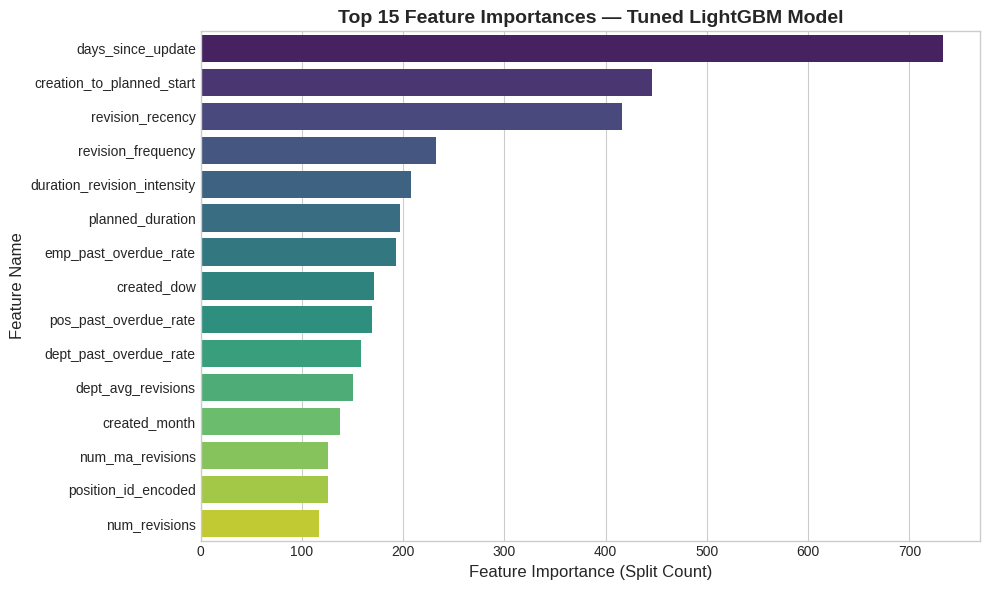

In [13]:
# Cell 10: Feature Importance Analysis (Tuned LightGBM Model)

feature_names = X_train_time.columns
importances = best_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("=== TOP 15 MOST IMPORTANT FEATURES ===")
print(df_importance.head(15).to_string(index=False))

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance.head(15),
    palette='viridis'
)
plt.title('Top 15 Feature Importances — Tuned LightGBM Model', fontweight='bold', fontsize=14)
plt.xlabel('Feature Importance (Split Count)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

### Overfitting Evaluation & Final Test Set Assessment

In [10]:
# Combine Train + Validation for final fitting before test evaluation
X_train_val = pd.concat([X_train_time, X_val_time])
y_train_val = pd.concat([y_train_time, y_val_time])

best_model.fit(X_train_val, y_train_val)

# Predict probabilities on Train+Val vs Held-Out Test Set
y_train_val_probs = best_model.predict_proba(X_train_val)[:, 1]
y_test_probs = best_model.predict_proba(X_test_time)[:, 1]

train_val_pr = average_precision_score(y_train_val, y_train_val_probs)
test_pr = average_precision_score(y_test_time, y_test_probs)

print("=== OVERFITTING & GENERALIZATION EVALUATION ===")
print(f"Train+Val PR-AUC : {train_val_pr:.4f}")
print(f"Held-Out Test PR-AUC : {test_pr:.4f}")
print(f"Generalization Gap   : {abs(train_val_pr - test_pr):.4f}")

# Final Test Set Classification Report at Threshold 0.40
y_test_preds = (y_test_probs >= 0.40).astype(int)
print("\n=== FINAL TEST SET CLASSIFICATION REPORT (Threshold = 0.40) ===")
print(classification_report(y_test_time, y_test_preds, target_names=['On-Time', 'Overdue']))


=== OVERFITTING & GENERALIZATION EVALUATION ===
Train+Val PR-AUC : 0.9357
Held-Out Test PR-AUC : 0.2355
Generalization Gap   : 0.7002

=== FINAL TEST SET CLASSIFICATION REPORT (Threshold = 0.40) ===
              precision    recall  f1-score   support

     On-Time       0.96      0.95      0.96      1977
     Overdue       0.24      0.27      0.25       108

    accuracy                           0.92      2085
   macro avg       0.60      0.61      0.60      2085
weighted avg       0.92      0.92      0.92      2085



## Random split Model Training 

### Preprocessing & Stratified Random 70/15/15 Split

In [15]:
# 1. Feature Engineering & Cleaning Function
def preprocess_and_engineer_features(df_input):
    df = df_input.copy()
    if 'planned_duration' in df.columns:
        df['planned_duration'] = df['planned_duration'].clip(lower=0)
    if 'num_ma_revisions' in df.columns:
        df['num_ma_revisions'] = df['num_ma_revisions'].clip(upper=78)
    if 'num_revisions' in df.columns:
        df['num_revisions'] = df['num_revisions'].clip(upper=9)

    challenge_cols = ['has_challenges', 'has_kpi_challenge', 'has_subtask_challenge', 'has_kpi_potential_challenge']
    existing_c = [c for c in challenge_cols if c in df.columns]
    if existing_c:
        df['total_challenge_load'] = df[existing_c].sum(axis=1)

    if 'num_revisions' in df.columns and 'has_challenges' in df.columns:
        df['persona_challenged_churn'] = ((df['num_revisions'] >= 3) & (df['has_challenges'] == 1)).astype(int)

    if 'is_cross_dept' in df.columns and 'kpi_is_overdue_flag' in df.columns:
        df['cross_dept_kpi_risk'] = ((df['is_cross_dept'] == 1) & (df['kpi_is_overdue_flag'] == 1)).astype(int)

    if 'planned_duration' in df.columns and 'num_revisions' in df.columns:
        df['duration_revision_intensity'] = df['num_revisions'] / (df['planned_duration'] + 1)

    cols_to_drop = [
        'id', 'ma_comment_count', 'wl_low', 'created_is_weekend',
        'created_is_friday', 'kpi_comment_count',
        'subtask_completion_pct', 'subtask_overdue_rate'
    ]
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 2. Load & Clean Dataset
df_raw = pd.read_csv('../data/v1/dataset_at_halfway.csv')
df_clean = preprocess_and_engineer_features(df_raw)

X = df_clean.drop(columns=['calculated_overdue'])
y = df_clean['calculated_overdue']

# 3. Stratified 70% Train, 15% Validation, 15% Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"=== STRATIFIED RANDOM SPLIT COMPLETED ===")
print(f"  • Train Set: {len(X_train):,} rows | Overdue Rate = {y_train.mean()*100:.2f}%")
print(f"  • Val Set:   {len(X_val):,} rows | Overdue Rate = {y_val.mean()*100:.2f}%")
print(f"  • Test Set:  {len(X_test):,} rows | Overdue Rate = {y_test.mean()*100:.2f}%")


=== STRATIFIED RANDOM SPLIT COMPLETED ===
  • Train Set: 9,726 rows | Overdue Rate = 20.10%
  • Val Set:   2,084 rows | Overdue Rate = 20.11%
  • Test Set:  2,085 rows | Overdue Rate = 20.10%


### Training Tuned Top 3 Models & Metric Benchmarking

In [16]:
# Initialize Tuned Models
models = {
    'LightGBM (Tuned)': lgb.LGBMClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1, n_jobs=-1
    ),
    'XGBoost (Tuned)': xgb.XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'Random Forest (Tuned)': RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=42, n_jobs=-1
    )
}

val_results = []
test_results = []
trained_models = {}
val_probs_dict = {}
test_probs_dict = {}

for name, model in models.items():
    # Fit on Train set
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Validation Set Evaluation (@ 0.40 threshold)
    val_probs = model.predict_proba(X_val)[:, 1]
    val_probs_dict[name] = val_probs
    val_preds = (val_probs >= 0.40).astype(int)
    p_v, r_v, f1_v, _ = precision_recall_fscore_support(y_val, val_preds, average='binary')
    
    val_results.append({
        'Model': name,
        'PR-AUC': round(average_precision_score(y_val, val_probs), 4),
        'ROC-AUC': round(roc_auc_score(y_val, val_probs), 4),
        'Precision@0.40': round(p_v, 4),
        'Recall@0.40': round(r_v, 4),
        'F1-Score@0.40': round(f1_v, 4)
    })

    # Held-Out Test Set Evaluation (@ 0.40 threshold)
    test_probs = model.predict_proba(X_test)[:, 1]
    test_probs_dict[name] = test_probs
    test_preds = (test_probs >= 0.40).astype(int)
    p_t, r_t, f1_t, _ = precision_recall_fscore_support(y_test, test_preds, average='binary')
    
    test_results.append({
        'Model': name,
        'PR-AUC': round(average_precision_score(y_test, test_probs), 4),
        'ROC-AUC': round(roc_auc_score(y_test, test_probs), 4),
        'Precision@0.40': round(p_t, 4),
        'Recall@0.40': round(r_t, 4),
        'F1-Score@0.40': round(f1_t, 4)
    })

print("=== VALIDATION SET RESULTS (STRATIFIED RANDOM SPLIT) ===")
print(pd.DataFrame(val_results).to_string(index=False))

print("\n=== HELD-OUT TEST SET RESULTS (STRATIFIED RANDOM SPLIT) ===")
print(pd.DataFrame(test_results).to_string(index=False))

=== VALIDATION SET RESULTS (STRATIFIED RANDOM SPLIT) ===
                Model  PR-AUC  ROC-AUC  Precision@0.40  Recall@0.40  F1-Score@0.40
     LightGBM (Tuned)  0.8360   0.9277          0.7926       0.7112         0.7497
      XGBoost (Tuned)  0.8443   0.9305          0.8217       0.7041         0.7584
Random Forest (Tuned)  0.8076   0.9111          0.8123       0.5990         0.6896

=== HELD-OUT TEST SET RESULTS (STRATIFIED RANDOM SPLIT) ===
                Model  PR-AUC  ROC-AUC  Precision@0.40  Recall@0.40  F1-Score@0.40
     LightGBM (Tuned)  0.8291   0.9341          0.7896       0.7255         0.7562
      XGBoost (Tuned)  0.8437   0.9389          0.8120       0.7422         0.7756
Random Forest (Tuned)  0.7921   0.9137          0.7957       0.6229         0.6988


### Visualizations — PR Curves, ROC Curves & Feature Importances

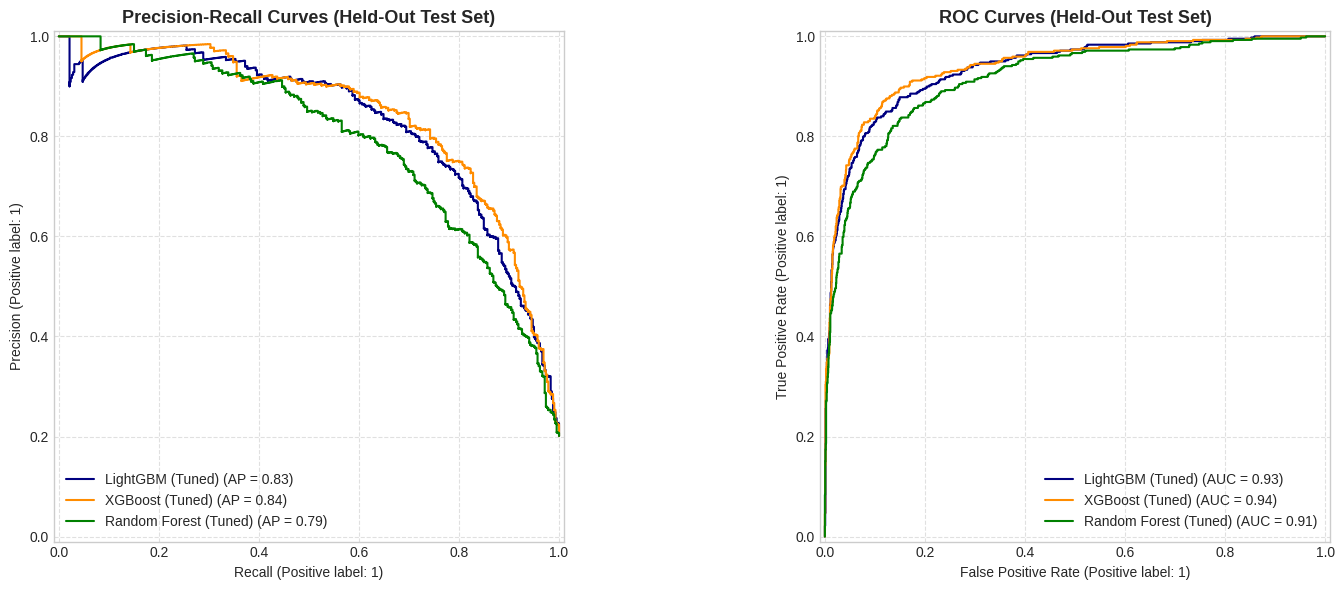

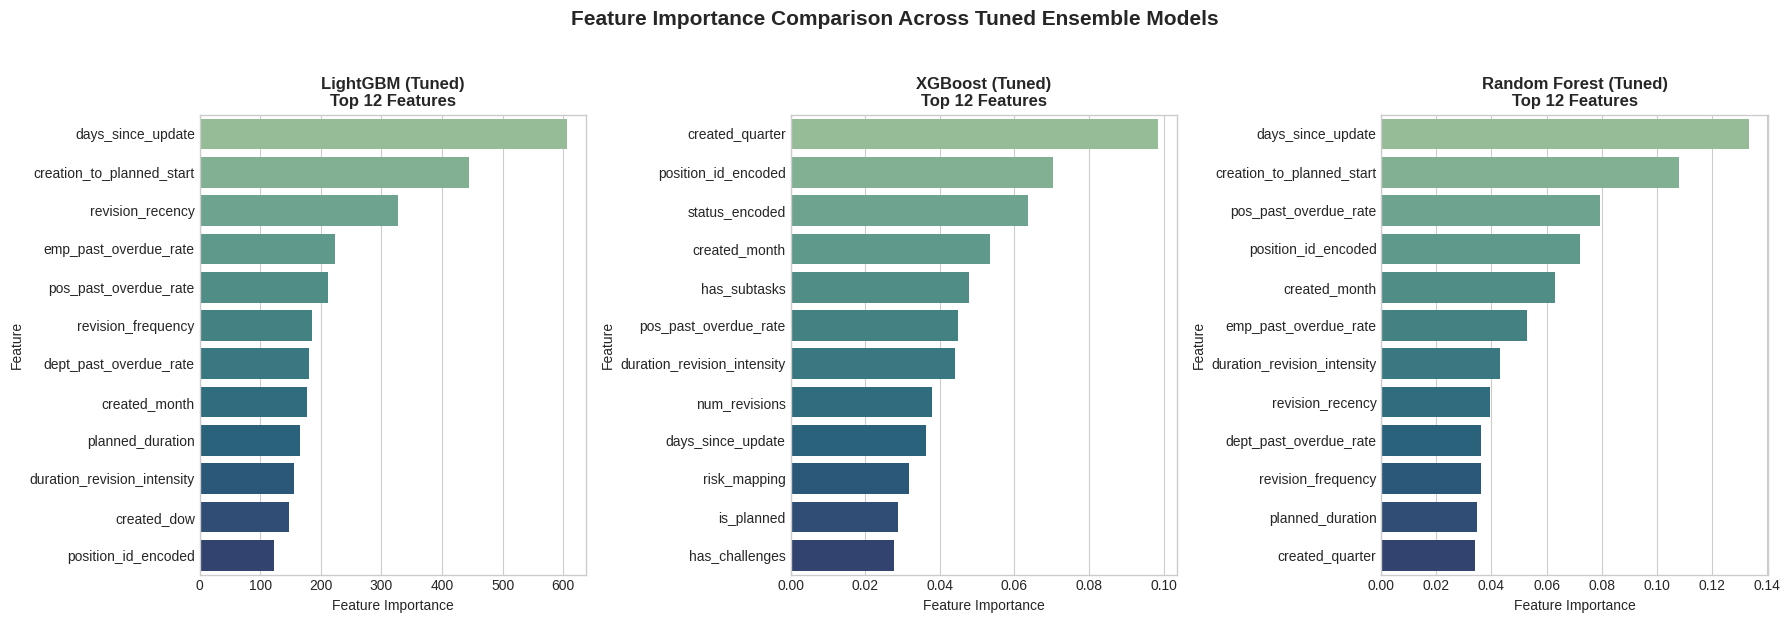

In [17]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'LightGBM (Tuned)': 'navy', 'XGBoost (Tuned)': 'darkorange', 'Random Forest (Tuned)': 'green'}

# 1. Precision-Recall Overlay Curves (Test Set)
for name, probs in test_probs_dict.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, name=name, ax=axes[0], color=colors[name]
    )
axes[0].set_title('Precision-Recall Curves (Held-Out Test Set)', fontweight='bold', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. ROC Overlay Curves (Test Set)

for name, probs in test_probs_dict.items():
    RocCurveDisplay.from_predictions(
        y_test, probs, name=name, ax=axes[1], color=colors[name]
    )
axes[1].set_title('ROC Curves (Held-Out Test Set)', fontweight='bold', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Top 12 Feature Importances Comparison Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, model) in enumerate(trained_models.items()):
    fi = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(12)

    sns.barplot(x='Importance', y='Feature', data=fi, ax=axes[idx], palette='crest')
    axes[idx].set_title(f'{name}\nTop 12 Features', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Feature Importance', fontsize=10)

plt.suptitle('Feature Importance Comparison Across Tuned Ensemble Models', fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


### 5-Fold Stratified Cross-Validation Benchmarking

In [19]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LightGBM (Tuned)': lgb.LGBMClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1, n_jobs=-1
    ),
    'XGBoost (Tuned)': xgb.XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    'Random Forest (Tuned)': RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=42, n_jobs=-1
    )
}

cv_summary = []
oof_probs_dict = {}
cv_trained_models = {}

for name, model in models.items():
    oof_probs = np.zeros(len(df_clean))
    pr_aucs, roc_aucs, precisions, recalls, f1s = [], [], [], [], []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        oof_probs[val_idx] = probs
        preds = (probs >= 0.40).astype(int)

        p, r, f1, _ = precision_recall_fscore_support(y_va, preds, average='binary')
        pr_aucs.append(average_precision_score(y_va, probs))
        roc_aucs.append(roc_auc_score(y_va, probs))
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    oof_probs_dict[name] = oof_probs
    
    # Store fitted model on full X for feature importance plot
    model.fit(X, y)
    cv_trained_models[name] = model

    cv_summary.append({
        'Model': name,
        'PR-AUC (Mean ± Std)': f"{np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}",
        'ROC-AUC (Mean ± Std)': f"{np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}",
        'Precision @ 0.40': f"{np.mean(precisions):.4f} ± {np.std(precisions):.4f}",
        'Recall @ 0.40': f"{np.mean(recalls):.4f} ± {np.std(recalls):.4f}",
        'F1-Score @ 0.40': f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}"
    })

print("=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===")
print(pd.DataFrame(cv_summary).to_string(index=False))


=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===
                Model PR-AUC (Mean ± Std) ROC-AUC (Mean ± Std) Precision @ 0.40   Recall @ 0.40 F1-Score @ 0.40
     LightGBM (Tuned)     0.8537 ± 0.0144      0.9370 ± 0.0068  0.8275 ± 0.0138 0.7132 ± 0.0181 0.7661 ± 0.0161
      XGBoost (Tuned)     0.8578 ± 0.0113      0.9379 ± 0.0072  0.8285 ± 0.0051 0.7186 ± 0.0181 0.7694 ± 0.0083
Random Forest (Tuned)     0.8115 ± 0.0130      0.9172 ± 0.0095  0.8252 ± 0.0144 0.6076 ± 0.0211 0.6996 ± 0.0152


###  OOF PR Curves, ROC Curves & Feature Importance Plots

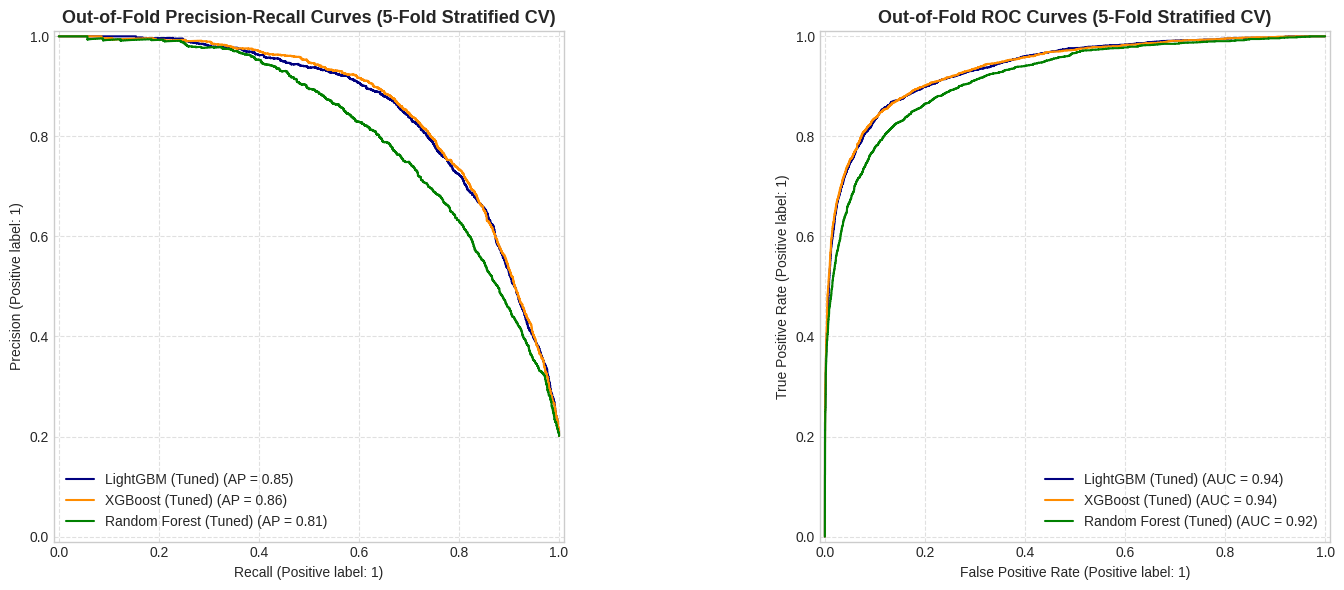

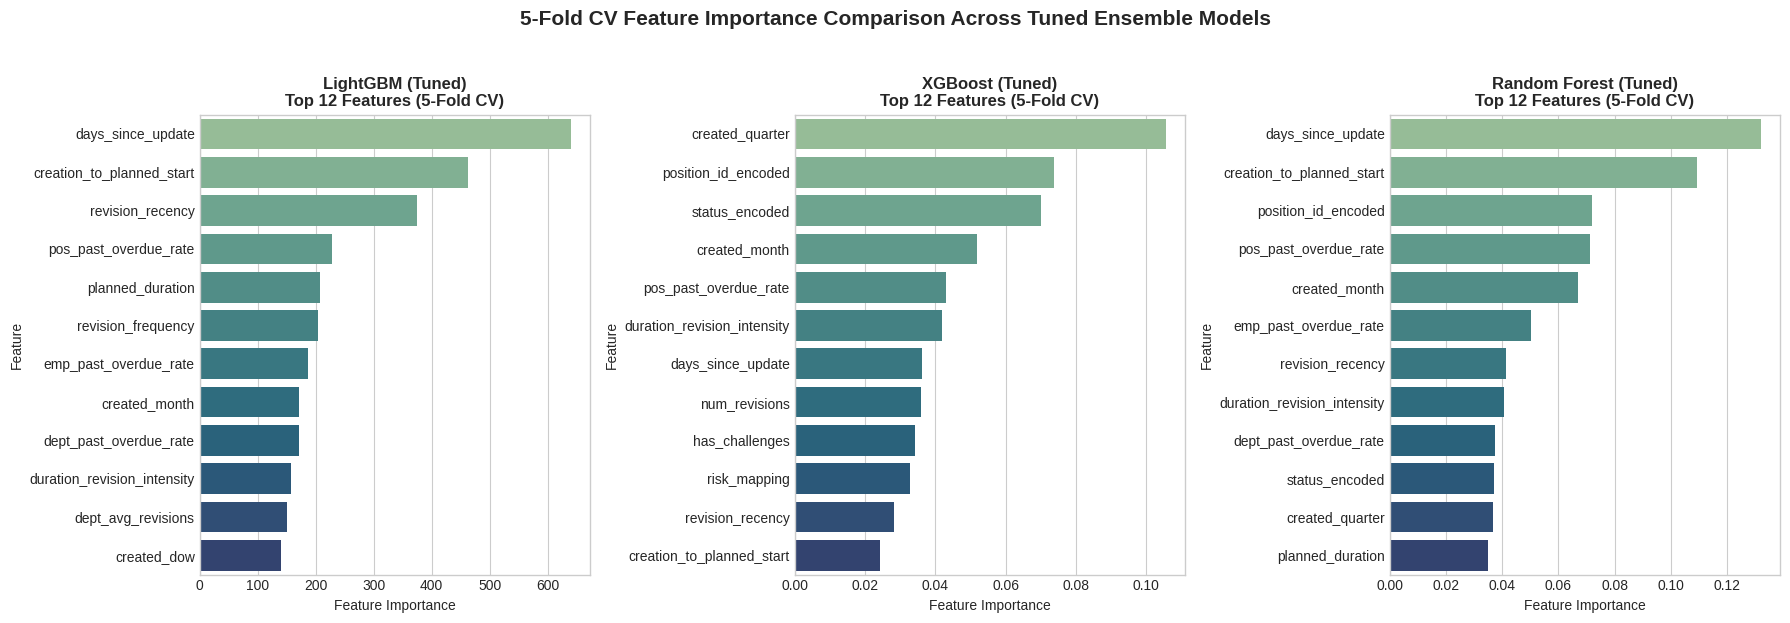

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'LightGBM (Tuned)': 'navy', 'XGBoost (Tuned)': 'darkorange', 'Random Forest (Tuned)': 'green'}

# 1. Out-of-Fold (OOF) Precision-Recall Overlay Curves
for name, oof_p in oof_probs_dict.items():
    PrecisionRecallDisplay.from_predictions(
        y, oof_p, name=name, ax=axes[0], color=colors[name]
    )
axes[0].set_title('Out-of-Fold Precision-Recall Curves (5-Fold Stratified CV)', fontweight='bold', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Out-of-Fold (OOF) ROC Overlay Curves
for name, oof_p in oof_probs_dict.items():
    RocCurveDisplay.from_predictions(
        y, oof_p, name=name, ax=axes[1], color=colors[name]
    )
axes[1].set_title('Out-of-Fold ROC Curves (5-Fold Stratified CV)', fontweight='bold', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Top 12 Feature Importances Plot Across CV Models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, model) in enumerate(cv_trained_models.items()):
    fi = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(12)

    sns.barplot(x='Importance', y='Feature', data=fi, ax=axes[idx], palette='crest')
    axes[idx].set_title(f'{name}\nTop 12 Features (5-Fold CV)', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Feature Importance', fontsize=10)

plt.suptitle('5-Fold CV Feature Importance Comparison Across Tuned Ensemble Models', fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()
